**Mô tả bài tập: Phân loại đa lớp sử dụng mô hình CLIP**

Phân loại đa lớp (multi-label classification) là bài toán trong đó **mỗi ảnh có thể thuộc về nhiều lớp cùng lúc**, thay vì chỉ một lớp duy nhất như bài toán phân loại truyền thống (single-label classification). Điều này phản ánh đúng hơn các tình huống trong thực tế, ví dụ: một bức ảnh có thể đồng thời chứa *dog*, *chair* và *sofa*.

Trong bài toán này, mục tiêu của mô hình là:
- Nhận một ảnh đầu vào.
- Dự đoán một **tập các nhãn** phù hợp với ảnh.

Khác với phân loại đơn lớp, mô hình phải xử lý mối quan hệ giữa nhiều nhãn cùng lúc, khiến bài toán trở nên phức tạp hơn nhưng cũng thực tế và hữu ích trong nhiều ứng dụng thị giác máy tính.

Trong bài tập này, chúng ta sẽ sử dụng mô hình **CLIP (Contrastive Language–Image Pre-training)** để giải quyết bài toán **phân loại đa lớp (multi-label classification)** trên tập dữ liệu hình ảnh. CLIP là mô hình được huấn luyện trước trên tập dữ liệu khổng lồ gồm hàng trăm triệu cặp văn bản – hình ảnh, giúp mô hình hiểu và liên kết được nội dung thị giác của ảnh với các mô tả ngôn ngữ tự nhiên.

**Mục tiêu của bài tập:**

- Sử dụng CLIP để trích xuất đặc trưng từ ảnh và từ các mô tả văn bản tương ứng với từng lớp (class text prompts).
- Tính toán độ tương đồng (similarity) giữa embedding ảnh và embedding văn bản.
- Xác định nhãn dự đoán cho ảnh bằng cách so sánh độ tương đồng với các lớp và chuyển kết quả thành dạng multi-label.
- Đánh giá khả năng phân loại đa lớp của CLIP trên tập dữ liệu đã cho.

Một điểm nổi bật của CLIP là mô hình hoạt động theo cơ chế **zero-shot**, tức là không cần huấn luyện lại. Chỉ cần cung cấp mô tả văn bản phù hợp cho từng lớp, mô hình có thể linh hoạt mở rộng sang nhiều nhiệm vụ phân loại khác nhau mà không cần fine-tuning.


**Import các thư viện cần thiết**

In [3]:
import json
import numpy as np
import torch
from PIL import Image
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, average_precision_score
from transformers import CLIPProcessor, CLIPModel
import random
import matplotlib.pyplot as plt
import os

**Load mô hình CLIP vào CPU để xử lý**

Trong đó *model* dùng để suy luận còn *processor* để xử lý dữ liệu

In [4]:
device    = "cpu"

model = CLIPModel.from_pretrained(
    "openai/clip-vit-base-patch32",
    local_files_only=True   # tạm comment dòng nếu dùng colab, dùng colab cần phải tải lại. Nhưng cần dòng này khi chạy trên hệ thống
).to("cpu")

processor = CLIPProcessor.from_pretrained(
    "openai/clip-vit-base-patch32",
    local_files_only=True   # tạm comment dòng nếu dùng colab, dùng colab cần phải tải lại. Nhưng cần dòng này khi chạy trên hệ thống
)


def unwrap_features(x):
    if isinstance(x, torch.Tensor):
        return x
    if hasattr(x, "pooler_output"):
        return x.pooler_output

C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\huggingface_hub\file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


**Tải dữ liệu test**

In [5]:
!gdown 1EwaMW_EklBR3KzWkMJ2lX-X20JIunWoY
!unzip -q VOC_CS431.zip

'gdown' is not recognized as an internal or external command,
operable program or batch file.
'unzip' is not recognized as an internal or external command,
operable program or batch file.


**Trực quan một số ví dụ**

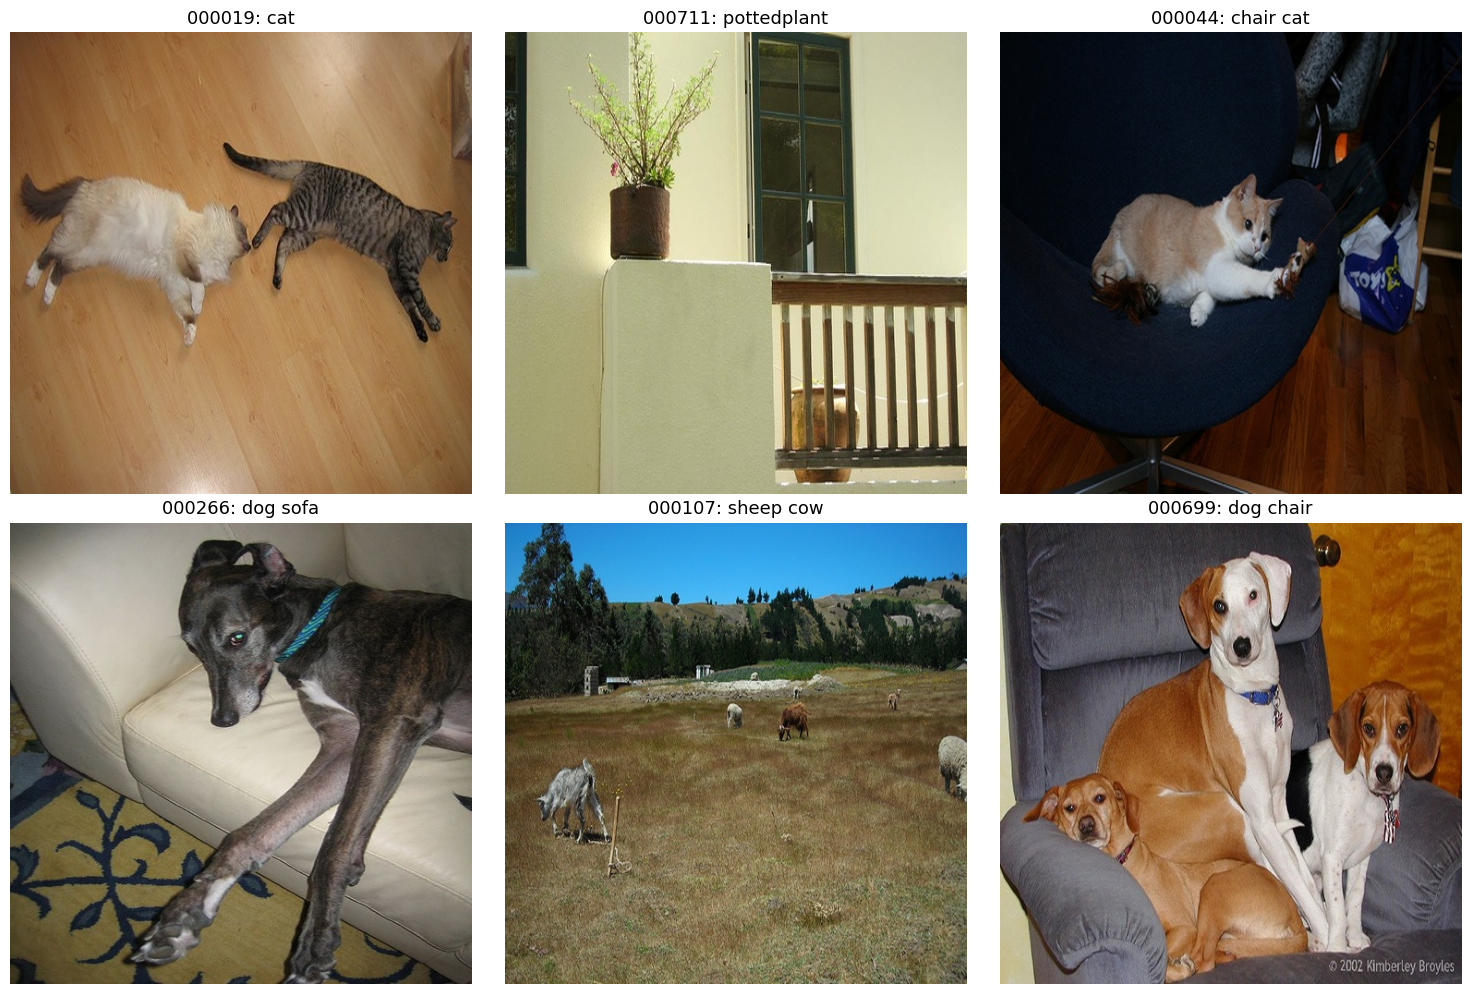

In [6]:
json_path = "./VOC_CS431/test.json"
with open(json_path, "r") as f:
    data = json.load(f)

IMAGE_DIR = "./VOC_CS431/VOC_CS431"

chosen_ids = ["000019", "000711", "000044", "000266", "000107", "000699"]

images = []
labels = []

for img_id in chosen_ids:
    img_path = os.path.join(IMAGE_DIR, f"{img_id}.jpg")

    if not os.path.exists(img_path):
        print(f"[WARNING] Không tìm thấy ảnh: {img_path}")
        continue

    # resize cho đồng nhất
    images.append(Image.open(img_path).resize((500, 500)))
    labels.append(data[img_id])   # ví dụ: "cat dog"

# ========================== Plot 6 ảnh ==========================
plt.figure(figsize=(15, 10))

for i, (img, lab) in enumerate(zip(images, labels)):
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(f"{chosen_ids[i]}: {lab}", fontsize=13)
    plt.axis("off")

plt.tight_layout()
plt.show()

**Thử nghiệm suy luận bằng mô hình CLIP với các lớp dự đoán** bao gồm *"dog", "cat", "potted plant", "chair", "sofa", "sheep", "cow"*

In [7]:
with open("./VOC_CS431/test.json", "r") as f:
    data = json.load(f)


prompts = [
    "dog",
    "cat",
    "potted plant",
    "chair",
    "sofa",
    "sheep",
    "cow"
]

image_ids = list(data.keys())
chosen_ids = ["000019", "000711", "000044", "000266", "000107", "000699"]

results = []

for img_id in chosen_ids:

    img_path = f"./VOC_CS431/VOC_CS431/{img_id}.jpg"
    image = Image.open(img_path).convert("RGB")
    img_inputs = processor(images=image, return_tensors="pt").to(device)
    text_inputs = processor(text=prompts, return_tensors="pt", padding=True).to(device)

    with torch.no_grad():
        image_embed = unwrap_features(model.get_image_features(**img_inputs))
        image_embed = image_embed / image_embed.norm()

        text_embeds = unwrap_features(model.get_text_features(**text_inputs))
        text_embeds = text_embeds / text_embeds.norm(dim=-1, keepdim=True)

    similarity = (image_embed @ text_embeds.T).squeeze(0)
    probs = similarity

    pred_list = []
    for cls, p in zip(prompts, probs.tolist()):
        pred_list.append(f"{cls}: {p:.2f}")

    pred_text = "\n".join(pred_list)

    results.append((img_id, image, pred_text, data[img_id]))

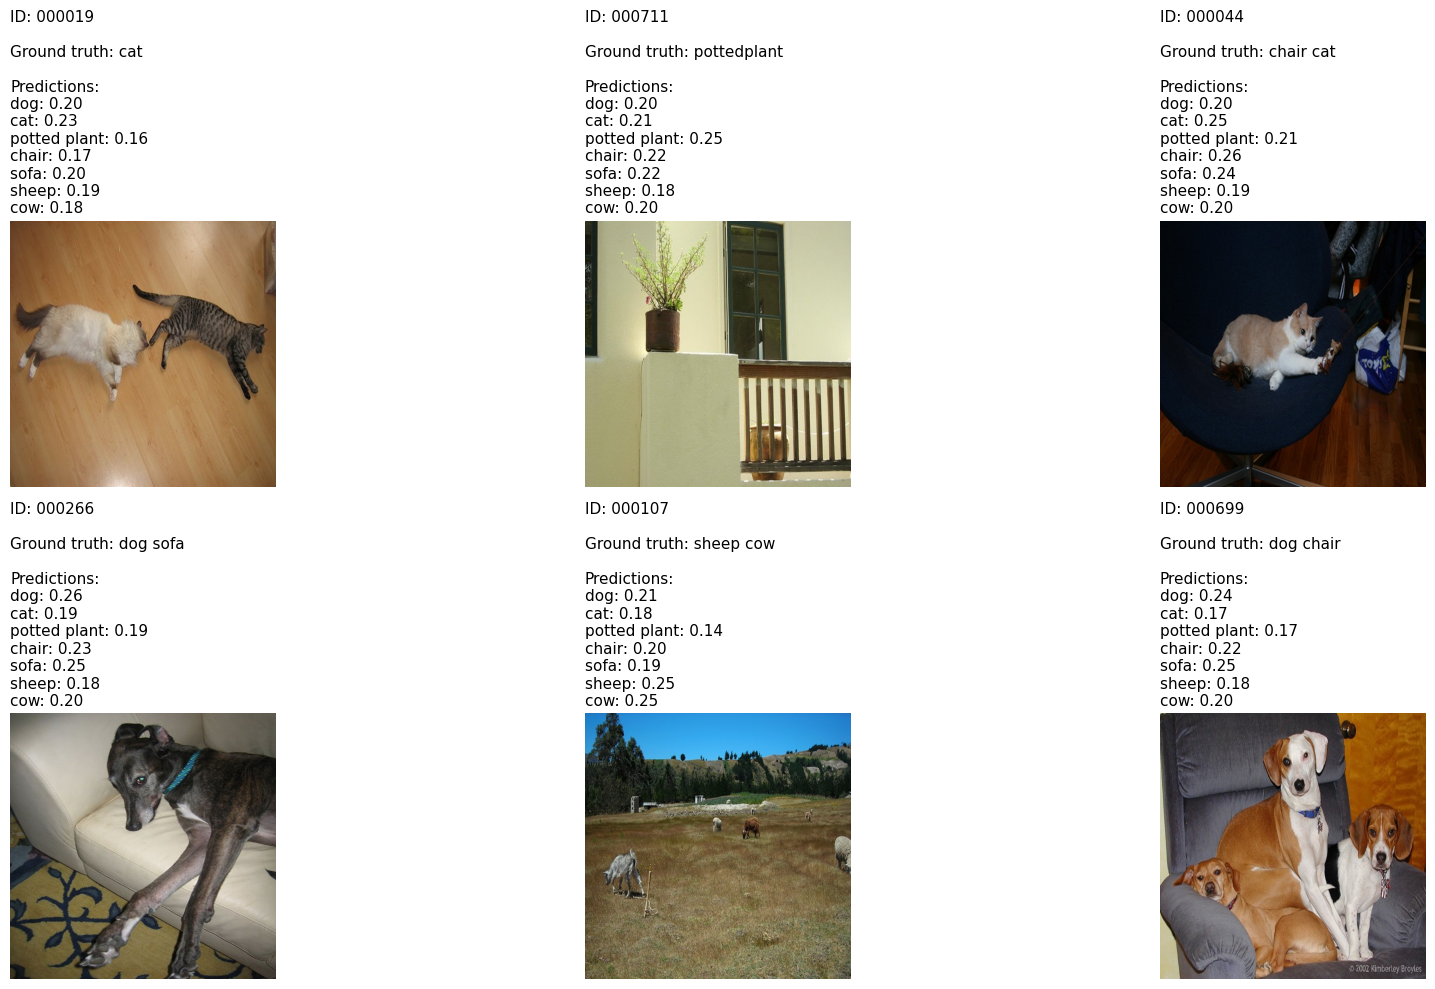

In [8]:
plt.figure(figsize=(18, 10))

for i, (img_id, img, pred_text, gt) in enumerate(results):
    plt.subplot(2, 3, i + 1)
    plt.imshow(img.resize((500, 500)))

    plt.title(
        f"ID: {img_id}\n\nGround truth: {gt}\n\nPredictions:\n{pred_text}",
        fontsize=11,
        loc="left"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

### Yêu cầu phần mã trong `BEGIN SOLUTION` và `END SOLUTION`

Trong phần này, bạn cần viết đoạn mã thực hiện việc dự đoán nhãn đa lớp cho các ảnh đầu vào.

**Input:**
- `json`: dữ liệu chứa danh sách ID ảnh và nhãn tương ứng (nhãn chỉ xuất hiện trong bộ public test).
- `classes`: danh sách các lớp cần dự đoán.
- Các ảnh được lưu trong thư mục quy định, mỗi ảnh có tên dạng `<id>.jpg`.

**Output:**
- Một dictionary `y_pred_dict` có cấu trúc:
  - **Key:** ID của ảnh (không bao gồm `.jpg`).
  - **Value:** vector multi-hot biểu diễn các lớp được mô hình dự đoán (ví dụ: `[0, 1, 0, 0, 1, ...]`).
- Độ dài vector bằng đúng số lớp trong `classes`.

Nhiệm vụ của bạn là đọc ảnh, chạy mô hình dự đoán, và chuyển kết quả thu được thành vector multi-hot theo đúng định dạng yêu cầu.

In [22]:
def run(json,classes):
    IMAGE_DIR = "./VOC_CS431/VOC_CS431"
    y_pred_dict = {}
    for img_id in json:
        y_pred_dict[img_id] = [0]*len(classes)
    ### BEGIN SOLUTION
    import os
    import torch
    from PIL import Image
    # 1. Danh sách ngưỡng bạn vừa tìm được
    per_class_thresholds = [0.2450, 0.2410, 0.2340, 0.2440, 0.2770, 0.2200, 0.2380, 0.2500, 0.2500]
    # 2. Chuẩn bị Prompt Ensemble (Dùng 3 mẫu phổ biến nhất)
    templates = ["a photo of a {}.", "a photo of the {}.", "a picture of a {}."]
    clean_names = [c.replace("pottedplant", "potted plant").replace("tvmonitor", "television monitor").replace("diningtable", "dining table") for c in classes]
    all_text_embeds = []
    for template in templates:
        prompts = [template.format(name) for name in clean_names]
        text_inputs = processor(text=prompts, return_tensors="pt", padding=True).to(device)
        with torch.no_grad():
            t_feat = unwrap_features(model.get_text_features(**text_inputs))
            all_text_embeds.append(t_feat / t_feat.norm(dim=-1, keepdim=True))
    
    text_embeds = torch.stack(all_text_embeds).mean(dim=0)
    text_embeds = text_embeds / text_embeds.norm(dim=-1, keepdim=True)
    # 3. Chạy inference cho từng ảnh
    for img_id in json:
        img_path = os.path.join(IMAGE_DIR, f"{img_id}.jpg")
        if not os.path.exists(img_path): continue
        
        try:
            image = Image.open(img_path).convert("RGB")
            img_inputs = processor(images=image, return_tensors="pt").to(device)
            
            with torch.no_grad():
                img_feat = unwrap_features(model.get_image_features(**img_inputs))
                img_feat = img_feat / img_feat.norm(dim=-1, keepdim=True)
                
            similarity = (img_feat @ text_embeds.T).squeeze(0)
            scores = similarity.tolist()
            
            # Dự đoán dựa trên bộ ngưỡng riêng
            y_pred_dict[img_id] = [1 if s > per_class_thresholds[i] else 0 for i, s in enumerate(scores)]
        except:
            continue



    ### END SOLUTION

    # trả về dictionary với key là tên ảnh (không bao gồm .jpg) và danh sách các lớp dự đoán dạng multi-hot
    #, số lượng bit của vector multi-hot dựa vào số lớp cần dự đoán
    # ví dụ {'000019': [0, 1, 0, 0, 0, 0, 0], '000107': [0, 0, 0, 0, 0, 1, 1], ...}
    return y_pred_dict

###  Sử dụng bộ dữ liệu `test.json` để kiểm tra hàm `def run(json,classes)` sau đó precision giữa kết quả dữ đoán và nhãn của các ảnh.

In [23]:
try:
    with open("./VOC_CS431/test.json", "r") as f:
        data_test = json.load(f)
    test_classes = ["dog", "cat", "pottedplant", "chair", "sofa", "sheep", "cow", "tvmonitor", "diningtable"]

    y_pred_dict = run(data_test,test_classes)
    y_true = []
    y_pred = []
    for img_id, labels in data_test.items():
        gt_vec = [1 if cls in labels.split() else 0 for cls in test_classes]
        y_true.append(gt_vec)
        y_pred.append(y_pred_dict[img_id])
    precision, _, _, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    print("Precision =", precision)

except Exception as e:
    print(f"❌ Lỗi: {type(e).__name__}: {e}")

Precision = 0.7777777777777778
